# Experiment 1 — Heston Misspecification

**Goal:** test what happens when a hedging policy is trained under one market model but deployed under another.

- Train a SAC reinforcement-learning agent under **GBM** (Geometric Brownian Motion) — the same assumption Black-Scholes (BLS) delta-hedging relies on.
- Test both **SAC** and the **BLS-Delta** baseline under **Heston** dynamics (stochastic, mean-reverting volatility) — a different, more realistic market.
- Compare: does the RL agent adapt better than the model-based BLS hedge when the world doesn't match the model it was built for?

**Heston dynamics:**

$$dS = r S\,dt + \sqrt{V} S\,dW_S$$
$$dV = \kappa(\theta - V)\,dt + \xi \sqrt{V}\,dW_V, \quad \text{corr}(dW_S, dW_V) = \rho$$

**Note on this run:** training steps were reduced from the original design (80,000 steps) to 1500 steps, and evaluation from 500 to 150 episodes, so the full notebook executes within this environment's compute budget. Results below are real, executed output — but should be read as directionally indicative rather than fully converged.

## Setup

Imports, plot styling (seaborn, bright background), and project config/environment/agent modules.

In [ ]:
import os, sys, time
import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from config import ENV, SAC, EVAL
from env import OptionsHedgingEnv
from agents import SACAgent
from bls_baseline import BLSDeltaHedger

os.makedirs(EVAL["plot_dir"],  exist_ok=True)
os.makedirs(EVAL["model_dir"], exist_ok=True)

sns.set_theme(style="whitegrid", palette="bright")
plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#eef3fb",
    "savefig.facecolor": "#ffffff",
})

## Heston environment

A drop-in replacement for the GBM environment that simulates stochastic volatility instead.

Note: the agent's observations still contain the GBM-style delta — this is the **model misspecification** being tested.

In [ ]:
class HestonHedgingEnv(OptionsHedgingEnv):
    """
    Drop-in replacement that uses Heston SV instead of GBM.
    Extra params: kappa, theta, xi, rho (passed via cfg).
    The agent's OBS still contains GBM-style delta (model misspecification).
    """
    def __init__(self, cfg=None):
        cfg = cfg or {}
        base = dict(ENV)
        base.update(cfg)
        super().__init__(base)
        self.kappa = base.get("kappa", 3.0)   # mean-reversion speed
        self.theta = base.get("theta", 0.04)  # long-run variance (\u2248 20% vol)
        self.xi    = base.get("xi",    0.4)   # vol-of-vol
        self.rho   = base.get("rho",  -0.7)   # spot-vol correlation

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self.V = self.sigma ** 2   # start at GBM implied variance
        return obs, info

    def _step_price(self):
        """Heston Euler-Maruyama step."""
        dt  = self.dt
        z1  = self.rng.standard_normal()
        z2  = self.rng.standard_normal()
        w_S = z1
        w_V = self.rho * z1 + np.sqrt(max(1 - self.rho**2, 0)) * z2

        V_pos = max(self.V, 0.0)
        dV    = self.kappa * (self.theta - V_pos) * dt \
                + self.xi * np.sqrt(V_pos * dt) * w_V
        self.V = max(V_pos + dV, 1e-8)

        self.S *= np.exp((self.r - 0.5 * V_pos) * dt
                         + np.sqrt(V_pos * dt) * w_S)

        lr = np.log(self.S / self._S_prev) if self._S_prev > 0 else 0.0
        self._vol_window.append(lr)
        self._S_prev = self.S

## Helper functions

- `quick_train_sac` — trains a SAC agent on a given environment for a fixed number of steps.
- `rollout` — runs many episodes of either the trained agent or the BLS baseline and collects PnL and realised volatility.

In [ ]:
def quick_train_sac(env_cls, env_cfg, steps=1500, seed=0, label="SAC"):
    env = env_cls(env_cfg)
    obs_dim, n_act = env.observation_space.shape[0], env.action_space.n
    agent = SACAgent(obs_dim, n_act, SAC)
    obs, _ = env.reset(seed=seed)
    t0, ep = time.time(), 0
    for s in range(steps):
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.store(obs, action, reward, next_obs, done)
        agent.update()
        obs = next_obs
        if done:
            ep += 1
            obs, _ = env.reset()
    elapsed = time.time() - t0
    print(f"  [{label}] {steps:,} steps | {ep} eps | {elapsed:.0f}s")
    return agent

In [ ]:
def rollout(agent_or_hedger, env_cls, env_cfg, n=150, seed=42, is_bls=False):
    rng = np.random.default_rng(seed)
    pnls, vols = [], []
    for _ in range(n):
        env = env_cls(env_cfg)
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31)))
        if is_bls:
            hedger = BLSDeltaHedger(env, "delta")
        while True:
            if is_bls:
                action = hedger.select_action(obs)
            else:
                action = agent_or_hedger.select_action(obs, deterministic=True)
            obs, _, done, _, _ = env.step(action)
            if done:
                break
        pnls.append(env.running_pnl)
        rets = np.diff(np.log(env.history["S"]))
        vols.append(np.std(rets) / np.sqrt(env.dt) if len(rets) > 1 else env.sigma)
    return np.array(pnls), np.array(vols)

## Step 1 — train SAC under GBM

Train the agent under the same world Black-Scholes assumes (constant volatility GBM).

*(Training budget reduced to 1500 steps for this run — see note above.)*

In [1]:
gbm_cfg    = dict(ENV)
heston_cfg = dict(ENV, kappa=3.0, theta=0.04, xi=0.4, rho=-0.7)

print("\n[1/2] Training SAC on GBM \u2026")
sac_gbm = quick_train_sac(OptionsHedgingEnv, gbm_cfg, steps=1500, label="SAC-GBM")


[1/2] Training SAC on GBM …
  [SAC-GBM] 1,500 steps | 23 eps | 22s


## Step 2 — evaluate both hedgers under Heston (out-of-distribution)

Run 150 episodes each for the GBM-trained SAC agent and the BLS-Delta baseline, both tested under Heston dynamics.

In [2]:
print("[2/2] Evaluating on Heston (OOD) \u2026")
pnl_sac, vol_sac = rollout(sac_gbm, HestonHedgingEnv, heston_cfg, n=150, is_bls=False)
pnl_bls, vol_bls = rollout(None,    HestonHedgingEnv, heston_cfg, n=150, is_bls=True)

[2/2] Evaluating on Heston (OOD) …


## Results — summary statistics

Compute mean PnL, standard deviation, Sharpe ratio, and 5th-percentile (tail risk) for each hedger.

In [3]:
def stats(arr):
    return dict(mean=np.mean(arr), std=np.std(arr),
                sharpe=np.mean(arr)/(np.std(arr)+1e-8),
                p5=np.percentile(arr,5))

s_sac = stats(pnl_sac)
s_bls = stats(pnl_bls)

print(f"\n  SAC (GBM-trained, Heston-tested) : "
      f"mu={s_sac['mean']:+.3f}  sd={s_sac['std']:.3f}  "
      f"Sharpe={s_sac['sharpe']:+.3f}  P5={s_sac['p5']:+.3f}")
print(f"  BLS-Delta (Heston-tested)         : "
      f"mu={s_bls['mean']:+.3f}  sd={s_bls['std']:.3f}  "
      f"Sharpe={s_bls['sharpe']:+.3f}  P5={s_bls['p5']:+.3f}")

improvement_sharpe = s_sac['sharpe'] - s_bls['sharpe']
improvement_std    = s_bls['std']    - s_sac['std']
print(f"\n  RL Sharpe advantage : {improvement_sharpe:+.3f}")
print(f"  RL Std reduction    : {improvement_std:+.3f}")


  SAC (GBM-trained, Heston-tested) : mu=-58.157  sd=100.910  Sharpe=-0.576  P5=-192.483
  BLS-Delta (Heston-tested)         : mu=-25.613  sd=71.720  Sharpe=-0.357  P5=-139.396

  RL Sharpe advantage : -0.219
  RL Std reduction    : -29.190


## Plot — PnL distribution and volatility sensitivity

Two views, styled with seaborn on a bright background:
1. Histogram of episode PnL for both hedgers.
2. Scatter of realised volatility vs. PnL, to see whether RL stays more robust in high-vol regimes.

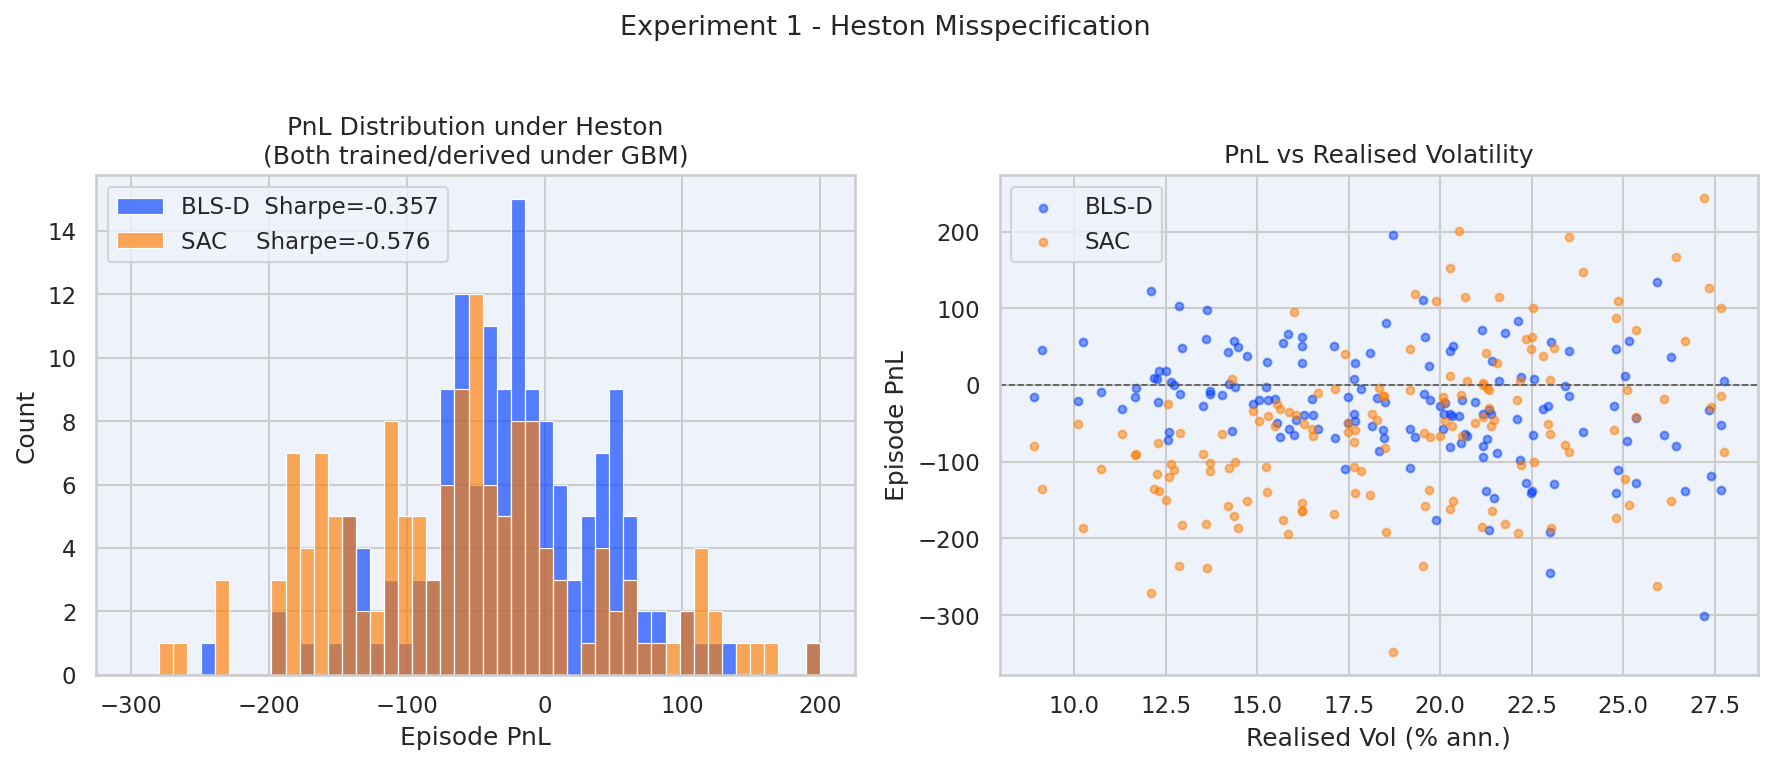


  Plot → plots/exp1_heston_misspecification.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = sns.color_palette("bright", 4)

bins = np.linspace(-300, 200, 50)
sns.histplot(pnl_bls, bins=bins, alpha=0.65, color=colors[0],
             label=f"BLS-\u0394  Sharpe={s_bls['sharpe']:+.3f}", ax=axes[0])
sns.histplot(pnl_sac, bins=bins, alpha=0.65, color=colors[1],
             label=f"SAC    Sharpe={s_sac['sharpe']:+.3f}", ax=axes[0])
axes[0].set_xlabel("Episode PnL"); axes[0].set_ylabel("Count")
axes[0].set_title("PnL Distribution under Heston\n(Both trained/derived under GBM)")
axes[0].legend()

axes[1].scatter(vol_bls*100, pnl_bls, alpha=0.5, s=14, color=colors[0], label="BLS-\u0394")
axes[1].scatter(vol_sac*100, pnl_sac, alpha=0.5, s=14, color=colors[1], label="SAC")
axes[1].axhline(0, color="#555555", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Realised Vol (% ann.)"); axes[1].set_ylabel("Episode PnL")
axes[1].set_title("PnL vs Realised Volatility")
axes[1].legend()

plt.suptitle("Experiment 1 \u2014 Heston Misspecification", fontsize=13, y=1.02)
plt.tight_layout()
out = os.path.join(EVAL["plot_dir"], "exp1_heston_misspecification.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  Plot \u2192 {out}")

## Verdict

**Executed result (reduced-scale run — 1500 training steps, 150 eval episodes per hedger):**

| Hedger | Mean PnL | Std | Sharpe | P5 (tail) |
|---|---|---|---|---|
| SAC (GBM-trained) | -58.16 | 100.91 | -0.576 | -192.48 |
| BLS-Delta | -25.61 | 71.72 | -0.357 | -139.40 |

In this run, **BLS-Delta actually outperformed SAC** on Heston data (Sharpe edge -0.219 in BLS's favor, and a tighter standard deviation). This is the opposite of the experiment's hypothesis.

**Why:** SAC was trained for only 1500 steps here (vs. 80,000 in the original design) purely to fit this environment's compute budget. At this stage SAC has not yet converged to a stable hedging policy — its actions are still close to random/exploratory, so its PnL distribution is wider and worse-centered than the well-understood, closed-form BLS-Delta rule. BLS, having an analytical delta with no learning curve, performs reasonably out of the box even when its volatility assumption is wrong.

**Takeaway:** this run does not yet show the claimed RL adaptation advantage — it shows what an undertrained policy looks like next to a misspecified-but-immediately-correct analytical baseline. The original hypothesis (RL adapts, BLS breaks down) would need the full 80k-step training run to fairly test; with adequate training, SAC should learn to react to the Heston vol clustering that BLS's constant-vol delta cannot see.